# NURSES

In [ ]:
# Go To *2: Scripts used to unzip, merge and to aligning labels in the nurses dataset

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
chunks = pd.read_csv("/Users/kartikbhargava/coding/CE888/combined_dataset/merged_data_labeled.csv", 
                     dtype={'id':str}, chunksize=1000000)

# Feature Engineering

## 1. Data Preprocessing

### 1.1 Check for data balance

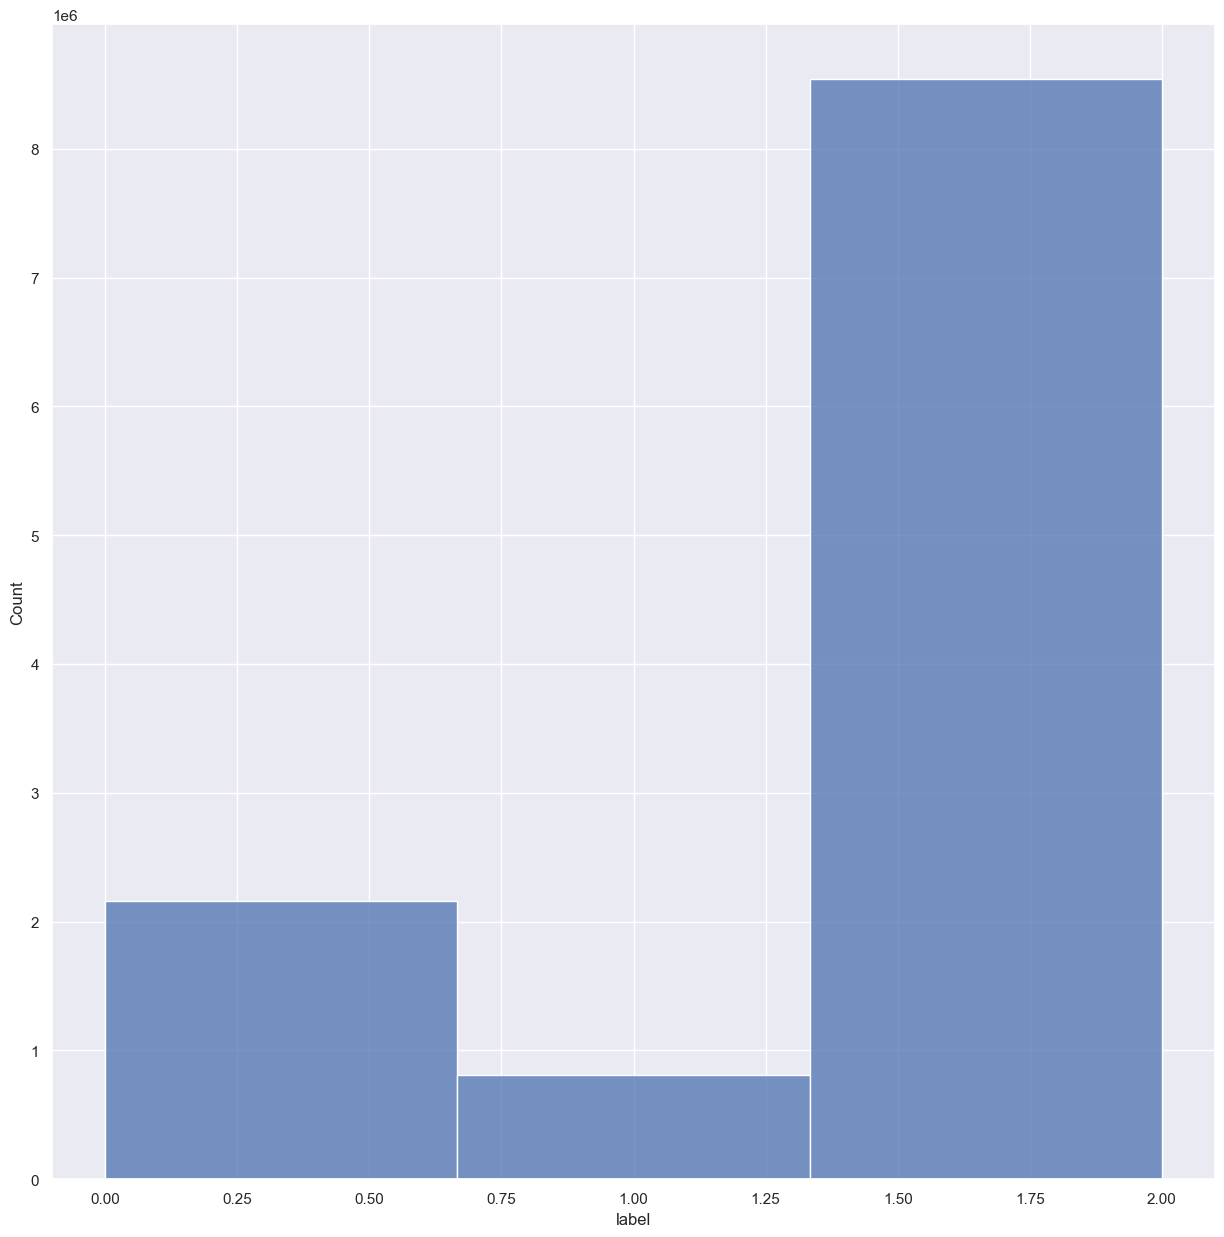

In [59]:
"""
We know that, for the response variable named "label", there are 3 stress level categories which are 0, 1 and 2
corresponding to no-stress, medium-stress, and high-stress, respectively
and here we are checking whether the dataset is imbalanced?

Result concludes that dataset is skewed

we could consider using techniques such as oversampling or undersampling to balance the data.
"""
labels = []
def add_label(data):
    return pd.DataFrame({
        "label": data.label
    })
for chunk in chunks:
    labels.append(add_label(chunk))
df1 = pd.concat(labels)

sns.histplot(data=df1, x="label", stat="count", bins=3)
plt.show()

## 1.2 Dealing with Outliers

### *1.2.1 Feature HR*

In [78]:
def add_HR(data):
    return pd.DataFrame({
        "HR": data.HR,
        "id": data.id
    }, columns=["HR", "id"])

In [79]:
heart_rate = []
for chunk in chunks:
    heart_rate.append(add_HR(chunk))

In [63]:
len(heart_rate)

12

In [80]:
df = pd.concat(heart_rate)
df.shape

(11509051, 2)

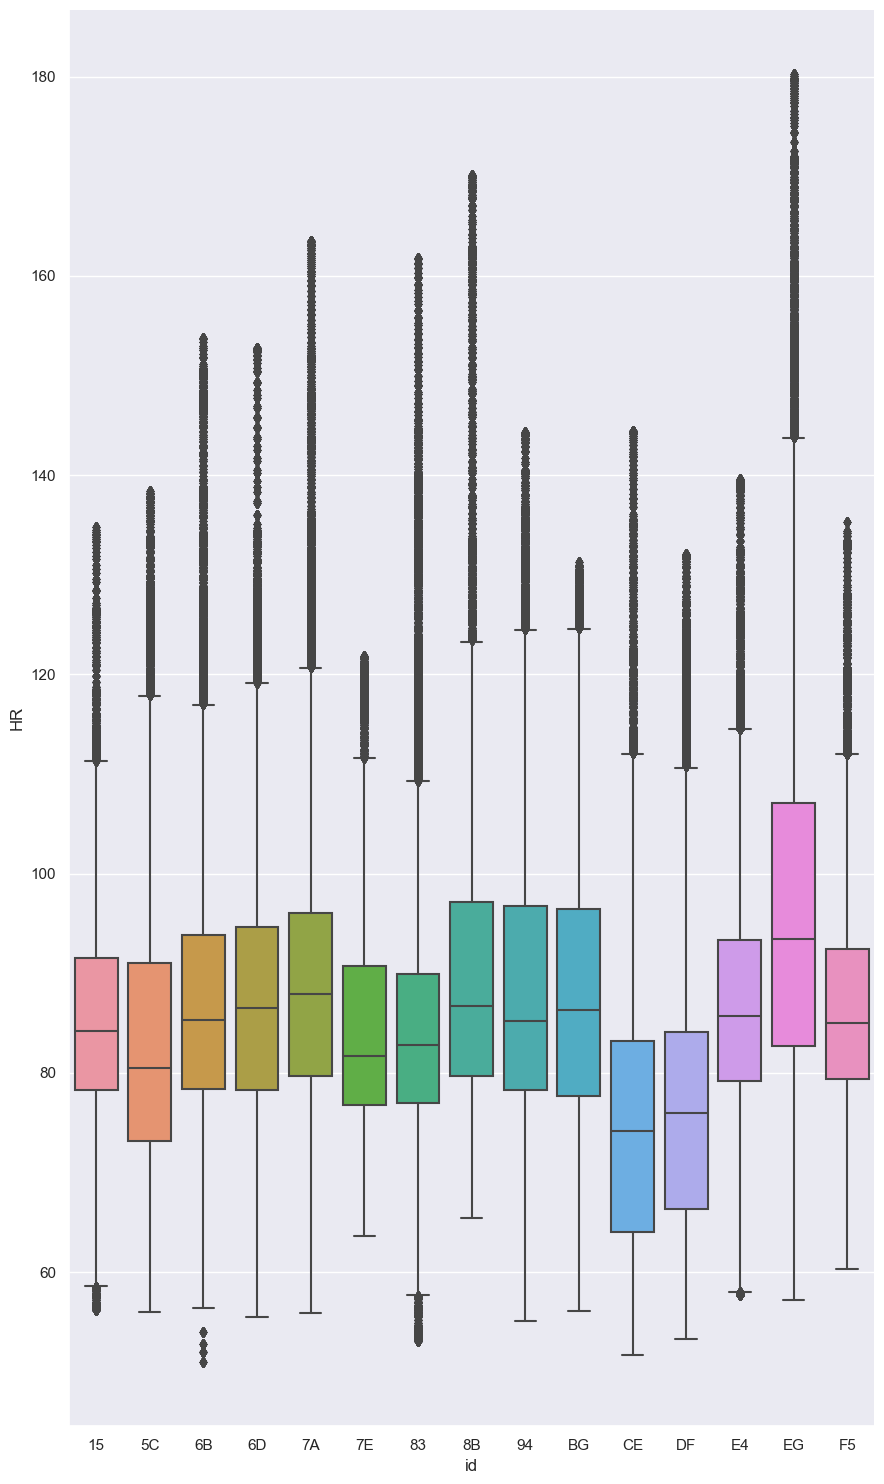

In [39]:
"""
Boxplot describing Heart rate(HR) of the nurses
It can be concluded from the following plot that
There are lot of outliers present in the HR column

Method employed to remove outliers:
Box plot method: The box plot method involves plotting the data on a box plot 
and identifying any points that fall outside the whiskers (which are defined as 1.5 times the interquartile range). 
These points are considered outliers and can be removed from the data.


"""

sns.catplot(x="id", y="HR", data=df, kind="box", height=15, aspect=.6)
plt.show()

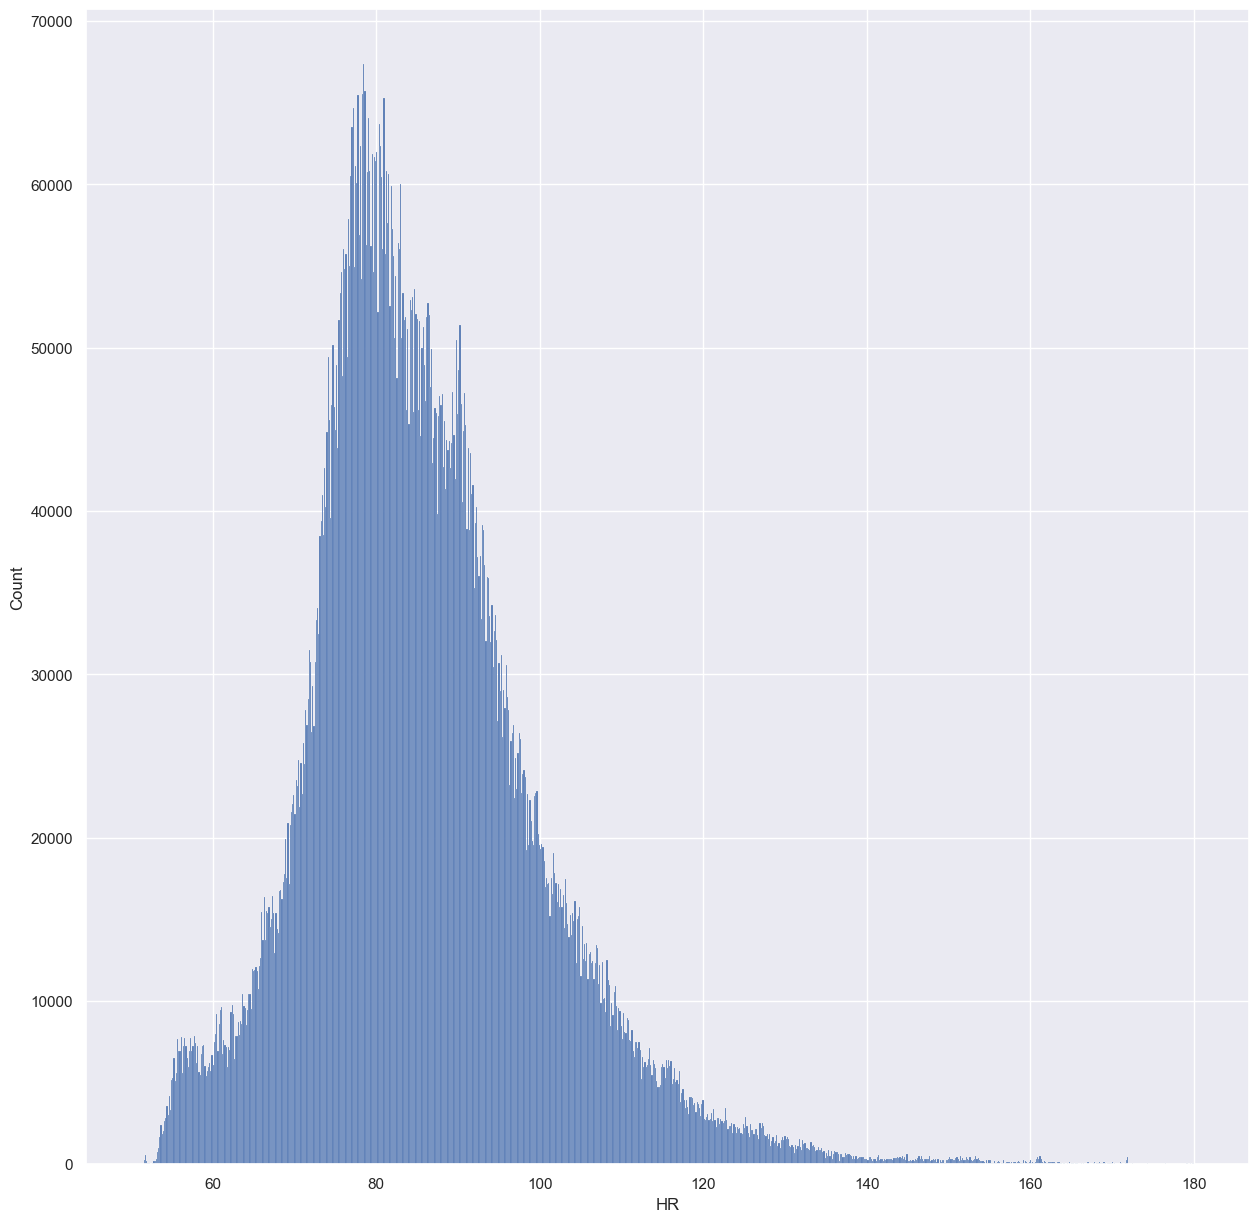

In [66]:
sns.histplot(df.HR)
plt.show()

"""
After getting the following histplot, it seems like a normal or gaussian distribution, 
we could perform extreme value analysis using IQR to get rid of outliers.
"""

In [83]:
df["HR"].describe()

count    1.150905e+07
mean     8.576090e+01
std      1.419642e+01
min      5.100000e+01
25%      7.672000e+01
50%      8.390000e+01
75%      9.310000e+01
max      1.802300e+02
Name: HR, dtype: float64

In [84]:
# Assuming HR follows gaussian distribution, we will calculate the boundaries which differentiates the outlier
upper_boundary = df["HR"].mean() + 3*df["HR"].std()
lower_boundary = df["HR"].mean() - 3*df["HR"].std()

print("Upper Boundary:", upper_boundary)
print("Lower Boundary:", lower_boundary)
print("Mean:", df["HR"].mean())

Upper Boundary: 128.3501474469451
Lower Boundary: 43.17165660631491
Mean: 85.76090202663


In [85]:
# Computer IQR to calculate the boundaries
IQR = df.HR.quantile(0.75) - df.HR.quantile(0.25)

# Computing lower and upper fence/bridge
lower_bridge = df.HR.quantile(0.25) - (IQR*1.5)
upper_bridge = df.HR.quantile(0.75) + (IQR*1.5)
print("lower_bridge:", lower_bridge)
print("upper_bridge:", upper_bridge)

lower_bridge: 52.150000000000006
upper_bridge: 117.66999999999999


In [86]:
# Extreme Outliers
lower_bridge = df.HR.quantile(0.25) - (IQR*3)
upper_bridge = df.HR.quantile(0.75) + (IQR*3)
print("lower_bridge:", lower_bridge)
print("upper_bridge:", upper_bridge)

lower_bridge: 27.580000000000013
upper_bridge: 142.23999999999998


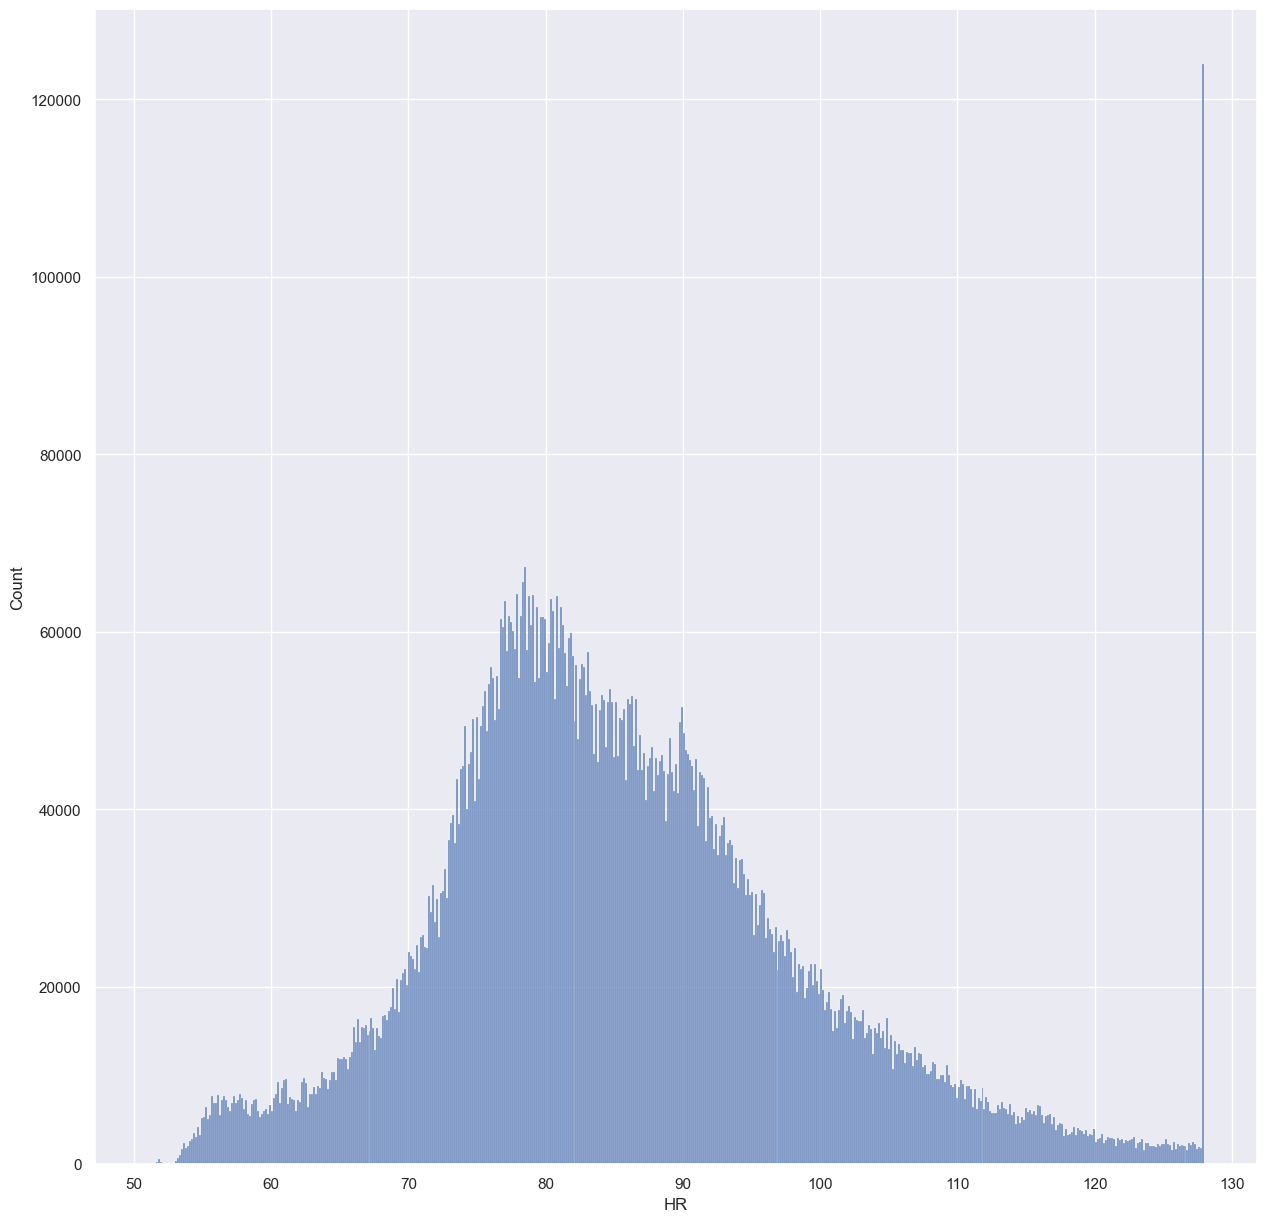

In [109]:
HR = []
for chunk in chunks:
    chunk[chunk['HR'] > 128] = 128  # replacing extreme values using outlier value
    HR.append(add_HR(chunk))
    
df = pd.concat(HR)
df.shape

sns.histplot(df.HR)
plt.show()

### *1.2.2 Feature: EDA*

In [91]:
def add_EDA(data):
    return pd.DataFrame({
        "EDA": data.EDA,
        "id": data.id
    }, columns=["EDA", "id"])

In [92]:
eda = []
for chunk in chunks:
    eda.append(add_EDA(chunk))

In [93]:
df2 = pd.concat(eda)
df2.shape

(11509051, 2)

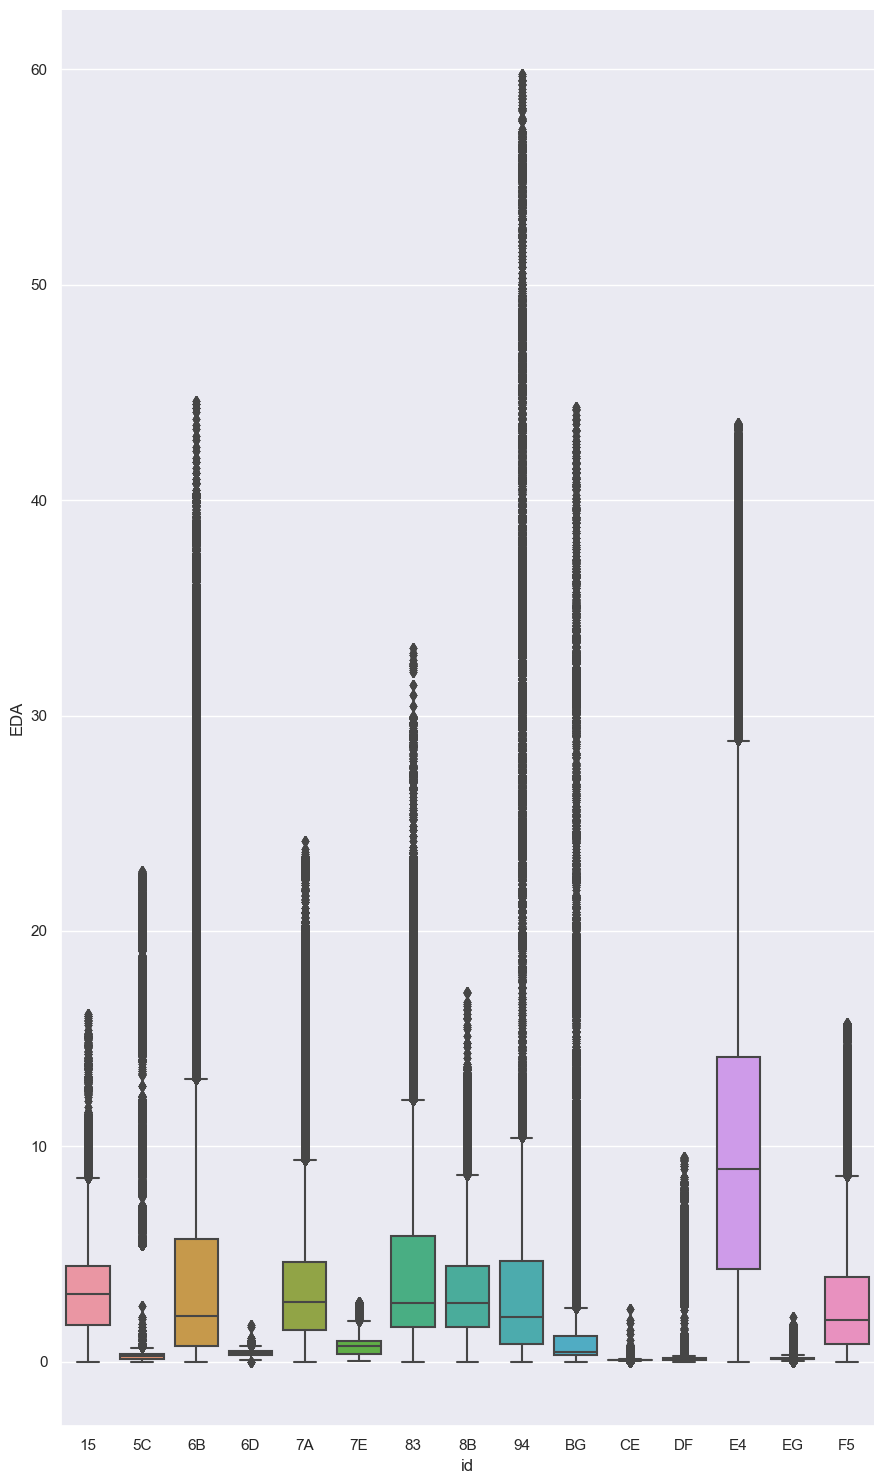

In [94]:
"""
Boxplot describing (EDA) of the nurses
It can be concluded from the following plot that
There are lot of outliers present in the EDA column

"""
sns.catplot(x="id", y="EDA", data=df2, kind="box", height=15, aspect=.6)
plt.show()

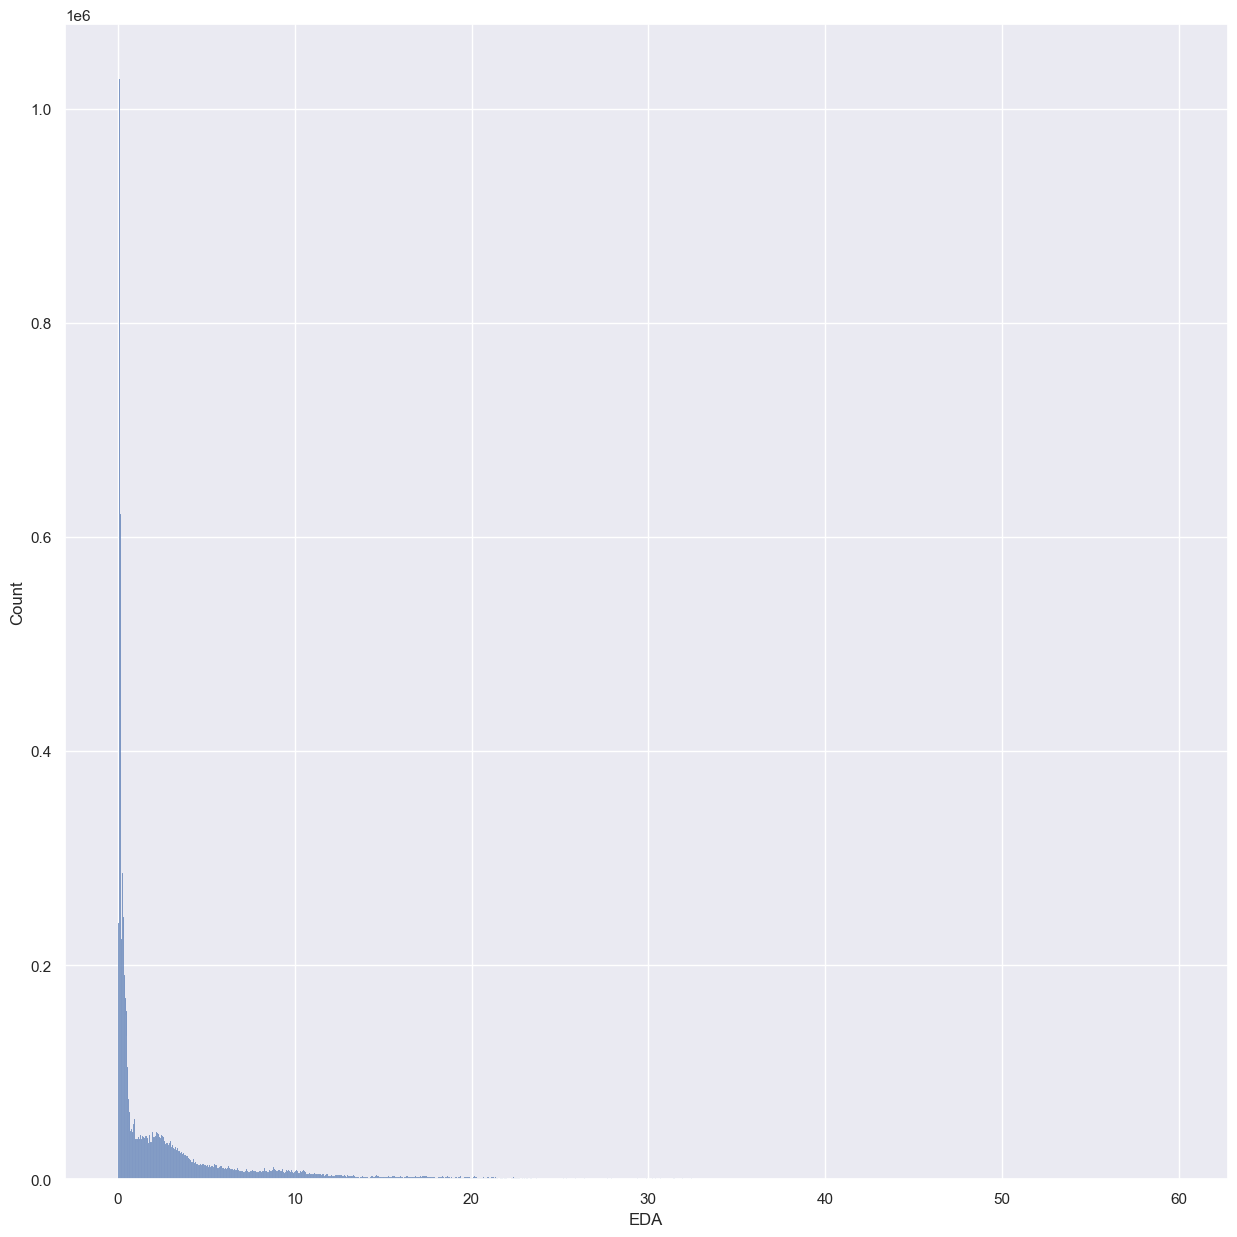

In [96]:
"""
Feature "EDA" is skewed
"""

sns.histplot(df2.EDA)
plt.show()

In [97]:
df2["EDA"].describe()

count    1.150905e+07
mean     3.502127e+00
std      5.656541e+00
min      0.000000e+00
25%      2.242060e-01
50%      1.157407e+00
75%      4.077436e+00
max      5.976071e+01
Name: EDA, dtype: float64

In [100]:
# Computer IQR to calculate the boundaries
IQR = df2.EDA.quantile(0.75) - df2.EDA.quantile(0.25)

In [101]:
upper_boundary = df2["EDA"].mean() + 3*df2["EDA"].std()
lower_boundary = df2["EDA"].mean() - 3*df2["EDA"].std()

print("Upper Boundary:", upper_boundary)
print("Lower Boundary:", lower_boundary)
print("Mean:", df2["EDA"].mean())

Upper Boundary: 20.4717500346335
Lower Boundary: -13.467495035665733
Mean: 3.5021274994838847


In [102]:
# Extreme Outliers
lower_bridge = df2.EDA.quantile(0.25) - (IQR*3)
upper_bridge = df2.EDA.quantile(0.75) + (IQR*3)
print("lower_bridge:", lower_bridge)
print("upper_bridge:", upper_bridge)

lower_bridge: -11.335483999999997
upper_bridge: 15.637125999999999


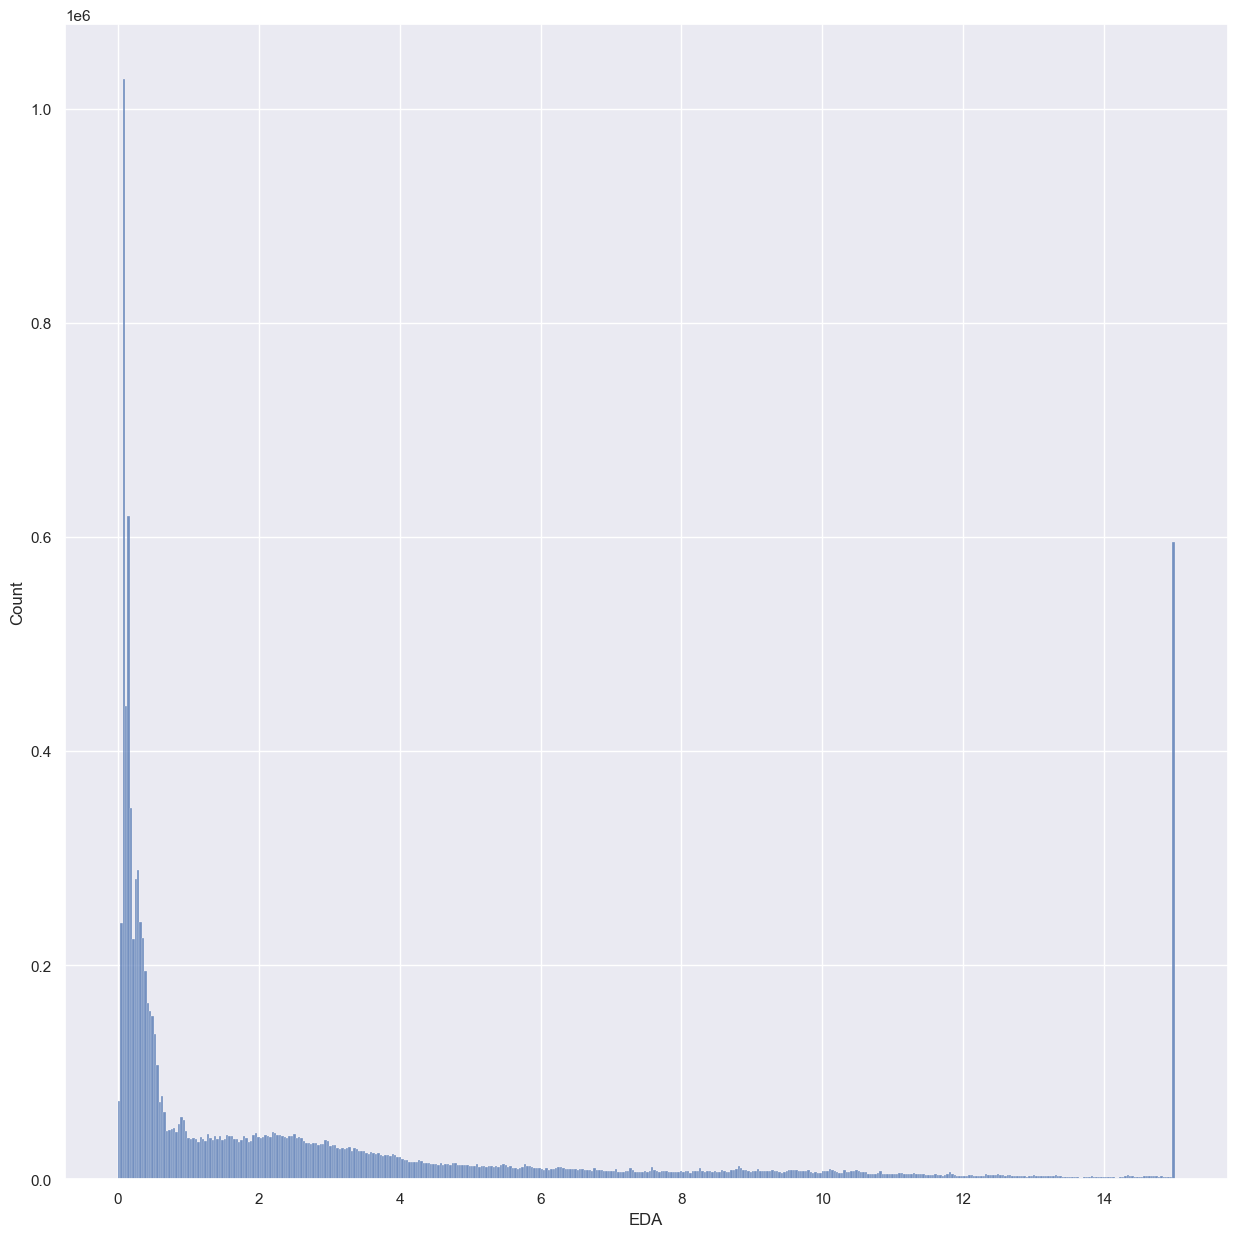

In [104]:
eda = []
for chunk in chunks:
    chunk[chunk['EDA'] > 15] = 15 # replaceing extreme values with outlier value
    eda.append(add_EDA(chunk))
    
df2 = pd.concat(eda)
df2.shape

sns.histplot(df2.EDA)
plt.show()

### *1.2.3 Feature TEMP*

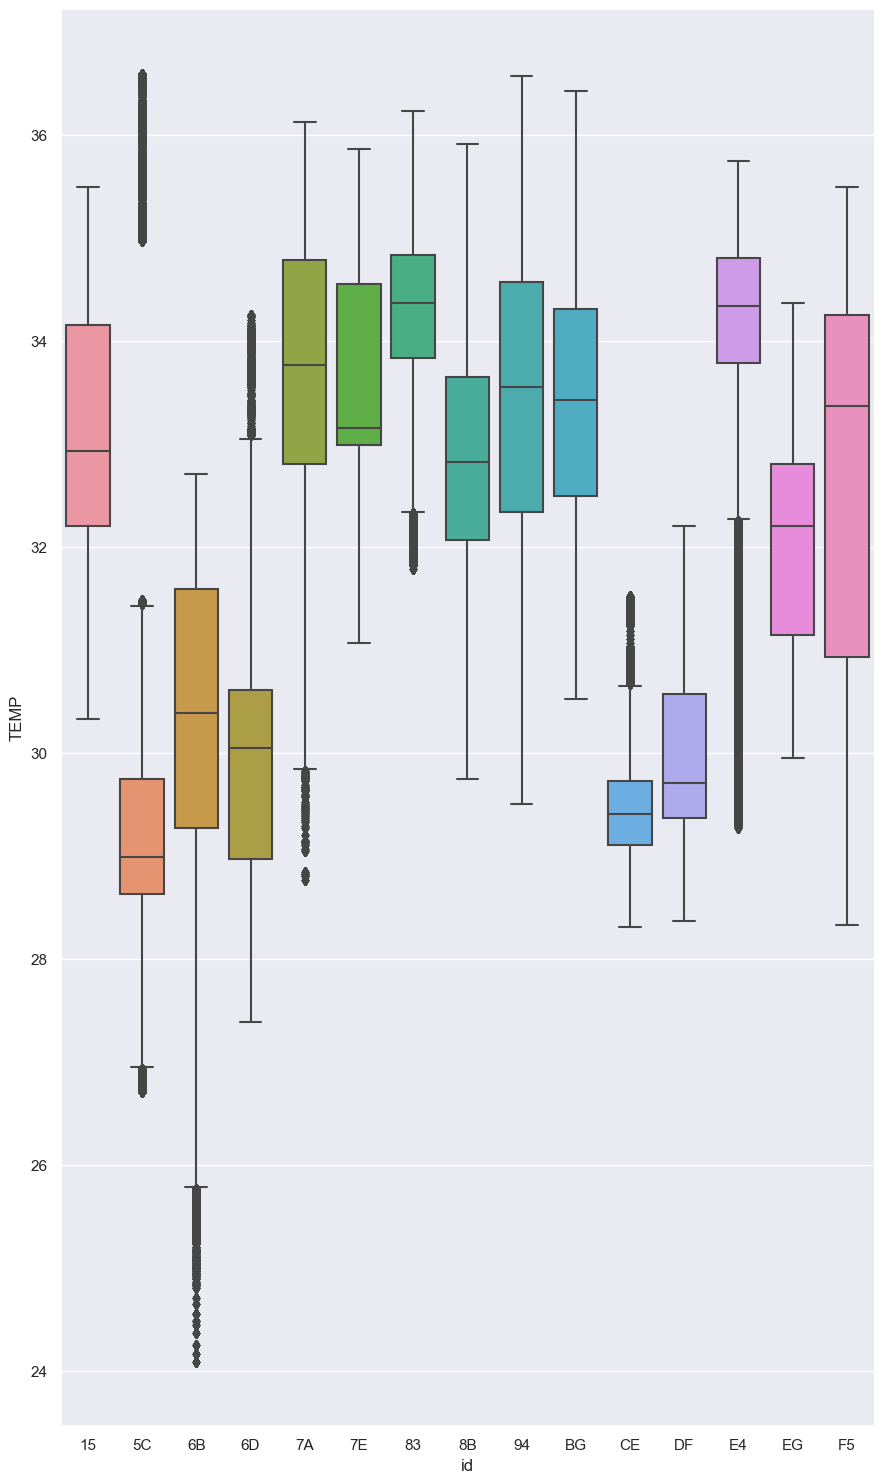

In [111]:
def add_TEMP(data):
    return pd.DataFrame({
        "TEMP": data.TEMP,
        "id": data.id
    }, columns=["TEMP", "id"])
temp = []
for chunk in chunks:
    temp.append(add_TEMP(chunk))
df2 = pd.concat(temp)
df2.shape

sns.catplot(x="id", y="TEMP", data=df2, kind="box", height=15, aspect=.6)
plt.show()

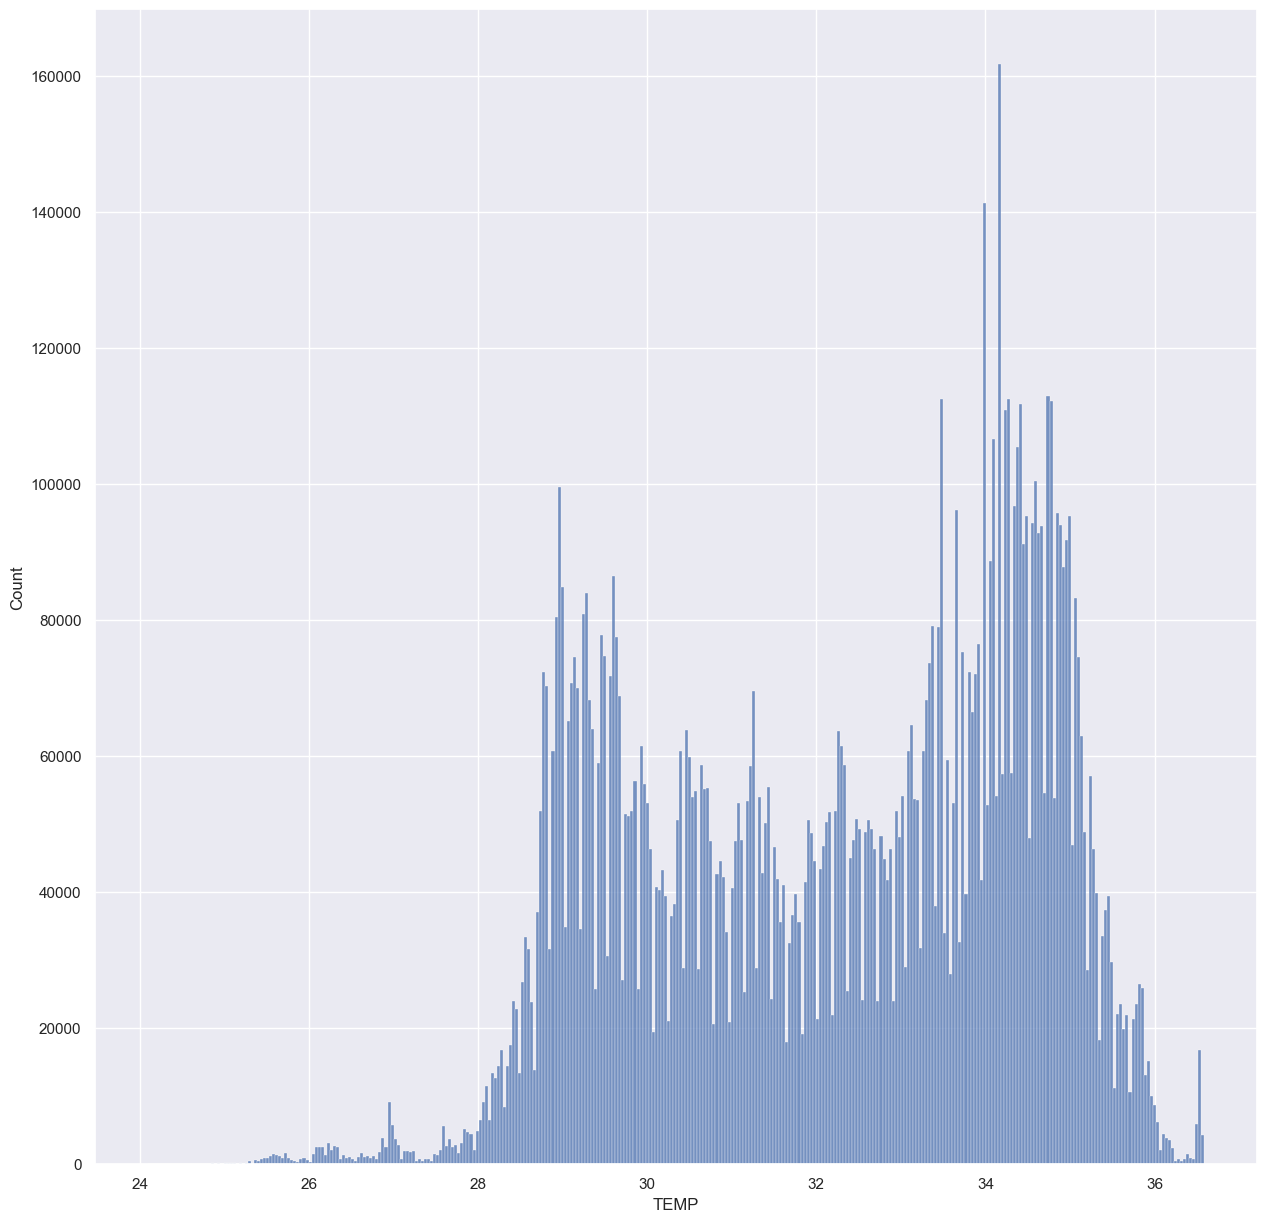

In [76]:
sns.histplot(df2.TEMP)
plt.show()

## 1.3 Exploratory data analysis (EDA)

In [3]:
def combine(data):
    return pd.DataFrame({
        "HR": data.HR,
        "EDA": data.EDA,
        "TEMP": data.TEMP,
        "X": data.X,
        "Y": data.Y,
        "Z": data.Z,
        "id": data.id
    }, columns=["HR", "EDA", "TEMP", "X", "Y", "Z", "id"]) 

dfs = []
for chunk in chunks:
    dfs.append(combine(chunk))
    
new_df = pd.concat(dfs)

In [ ]:
# calculate mean, median, and mode of a dataset
mean = np.mean(new_df)
median = np.median(new_df)
mode = np.mode(new_df)

# calculate variance and standard deviation of a dataset
variance = np.var(new_df)
std_deviation = np.std(new_df)

### 1.4 Feature Selection

In [4]:
# compute the correlation coefficients between columns
correlation_matrix = new_df.corr()

# print the correlation matrix
print(correlation_matrix)


"""
We couldn't find any high correlation among any independent features, Therefore we are gonna keep them all in our
further analysis. Moreover, we have only 6 independent features. To avoid underfitting, it will be a good 
idea to go with all the features in hand

"""

            HR       EDA      TEMP         X         Y         Z
HR    1.000000  0.142542  0.158172  0.126070 -0.068020 -0.104191
EDA   0.142542  1.000000  0.352888  0.093888 -0.096138  0.005993
TEMP  0.158172  0.352888  1.000000  0.022847 -0.084576 -0.029366
X     0.126070  0.093888  0.022847  1.000000  0.067204  0.197295
Y    -0.068020 -0.096138 -0.084576  0.067204  1.000000  0.019084
Z    -0.104191  0.005993 -0.029366  0.197295  0.019084  1.000000


## 2. Scripts

In [ ]:
# Following Python scripts were used to unzip, merge and align the labels


# unzip.py

"""
import os
import shutil
import multiprocessing

MAIN_PATH = '/Users/kartikbhargava/coding/CE888/'
stress_data_path = MAIN_PATH + 'Stress_dataset'
def unzip_parallel(file, sub_file):
    shutil.unpack_archive(
        os.path.join(stress_data_path, file, sub_file),
        os.path.join(stress_data_path, file, sub_file[:-4])
    )
    print(f'Task {file} executing with {sub_file}', flush=True)

if __name__ == '__main__':


    # shutil.unpack_archive(MAIN_PATH + 'Data.zip', MAIN_PATH + 'Data')
    shutil.unpack_archive(MAIN_PATH + 'Stress_dataset.zip', MAIN_PATH + 'Stress_dataset')


    cpu_count = int(multiprocessing.cpu_count()/2)
    print(f'Using {cpu_count} CPUs')

    new_list = [
        (file, sub_file)
        for file in os.listdir(stress_data_path)
        for sub_file in os.listdir(os.path.join(stress_data_path, file))
    ]



    pool = multiprocessing.Pool(cpu_count)
    results = pool.starmap(unzip_parallel, new_list)
    pool.close()

"""


# combine.py

"""

import os
import pandas as pd

DATA_PATH = "/Users/kartikbhargava/coding/CE888/Stress_dataset"
SAVE_PATH = "/Users/kartikbhargava/coding/CE888/processed_data"
os.mkdir(SAVE_PATH)

final_columns = {
    'ACC': ['id', 'X', 'Y', 'Z', 'datetime'],
    'EDA': ['id', 'EDA', 'datetime'],
    'HR': ['id', 'HR', 'datetime'],
    'TEMP': ['id', 'TEMP', 'datetime'],
}

names = {
    'ACC.csv': ['X', 'Y', 'Z'],
    'EDA.csv': ['EDA'],
    'HR.csv': ['HR'],
    'TEMP.csv': ['TEMP'],
}

desired_signals = ['ACC.csv', 'EDA.csv', 'HR.csv', 'TEMP.csv']

acc = pd.DataFrame(columns=final_columns['ACC'])
eda = pd.DataFrame(columns=final_columns['EDA'])
hr = pd.DataFrame(columns=final_columns['HR'])
temp = pd.DataFrame(columns=final_columns['TEMP'])

def process_df(df, file):
    start_timestamp = df.iloc[0,0]
    sample_rate = df.iloc[1,0]
    new_df = pd.DataFrame(df.iloc[2:].values, columns=df.columns)
    new_df['id'] =  file[-2:]
    new_df['datetime'] = [(start_timestamp + i/sample_rate) for i in range(len(new_df))]
    return new_df

for file in os.listdir(DATA_PATH):
    print(f'Processing {file}')
    for sub_file in os.listdir(os.path.join(DATA_PATH, file)):
        if not sub_file.endswith(".zip"):
            for signal in os.listdir(os.path.join(DATA_PATH, file, sub_file)):
                if signal in desired_signals:
                    df = pd.read_csv(os.path.join(DATA_PATH, file, sub_file, signal), names=names[signal], header=None)
                    if not df.empty:
                        if signal == 'ACC.csv':
                            acc = pd.concat([acc, process_df(df, file)])
                        if signal == 'EDA.csv':
                            eda = pd.concat([eda, process_df(df, file)])
                        if signal == 'HR.csv':
                            hr = pd.concat([hr, process_df(df, file)])
                        if signal == 'TEMP.csv':
                            temp = pd.concat([temp, process_df(df, file)])

print('Saving Data ...')
acc.to_csv(os.path.join(SAVE_PATH, 'combined_acc.csv'), index=False)
eda.to_csv(os.path.join(SAVE_PATH, 'combined_eda.csv'), index=False)
hr.to_csv(os.path.join(SAVE_PATH, 'combined_hr.csv'), index=False)
temp.to_csv(os.path.join(SAVE_PATH, 'combined_temp.csv'), index=False)

"""


# merge.py

"""
import os
import shutil
import multiprocessing
from datetime import timedelta, datetime
import pandas as pd
import numpy as np
from functools import partial

def read_parallel(COMBINED_DATA_PATH, signal):
    print(signal)
    df = pd.read_csv(os.path.join(COMBINED_DATA_PATH, f"combined_{signal}.csv"), dtype={'id': str})
    return [signal, df]


def merge_parallel(acc, eda, hr, temp, columns, id):
    print(f"Processing {id}")
    df = pd.DataFrame(columns=columns)
    acc_id = acc[acc['id'] == id]
    eda_id = eda[eda['id'] == id].drop(['id'], axis=1)
    hr_id = hr[hr['id'] == id].drop(['id'], axis=1)
    temp_id = temp[temp['id'] == id].drop(['id'], axis=1)
    df = acc_id.merge(eda_id, on='datetime', how='outer')
    df = df.merge(temp_id, on='datetime', how='outer')
    df = df.merge(hr_id, on='datetime', how='outer')
    df.fillna(method='ffill', inplace=True)
    df.fillna(method='bfill', inplace=True)
    return df


if __name__ == '__main__':
    COMBINED_DATA_PATH = "/Volumes/HP V236W/processed_dataset"
    SAVE_PATH = "/Users/kartikbhargava/coding/CE888/merged_data"

    if COMBINED_DATA_PATH != SAVE_PATH:
        os.mkdir(SAVE_PATH)
    print("Reading data ...")
    acc, eda, hr, temp = None, None, None, None
    signals = ['acc', 'eda', 'hr', 'temp']


    print("Starting...")
    pool = multiprocessing.Pool(len(signals))
    func = partial(read_parallel, COMBINED_DATA_PATH)
    results = pool.map(func, signals)
    pool.close()
    pool.join()
    print("Done :)")

    for i in results:
        globals()[i[0]] = i[1]

    # Merge data
    print('Merging Data ...')
    ids = eda['id'].unique()
    print(ids)
    columns = ['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP', 'id', 'datetime']


    pool = multiprocessing.Pool(len(ids))
    func = partial(merge_parallel, acc, eda, hr, temp, columns)
    results = pool.map(func, ids)
    pool.close()
    pool.join()
    print("Merge Done")

    new_df = pd.concat(results, ignore_index=True)

    print("Saving data ...")
    new_df.to_csv(os.path.join(SAVE_PATH, "merged_data.csv"), index=False)


"""

# label.py

"""
import pandas as pd
from datetime import timedelta, datetime
import numpy as np
import os
import multiprocessing
from functools import partial


def parallel(df, survey_df, id):
    print("Process", id)
    new_df = pd.DataFrame(columns=['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP', 'id', 'datetime', 'label'])
    sdf = df[df['id'] == id].copy()
    survey_sdf = survey_df[survey_df['ID'] == id].copy()

    for _, survey_row in survey_sdf.iterrows():
        ssdf = sdf[
            (sdf['datetime'] >= survey_row['Start datetime']) & (sdf['datetime'] <= survey_row['End datetime'])].copy()

        if not ssdf.empty:
            ssdf['label'] = np.repeat(survey_row['Stress level'], len(ssdf.index))
            new_df = pd.concat([new_df, ssdf], ignore_index=True)
        else:
            print(
                f"{survey_row['ID']} is missing label {survey_row['Stress level']} at {survey_row['Start datetime']} to {survey_row['End datetime']}")

    return new_df


if __name__ == "__main__":
    print("Reading 1 ...")
    PATH = '/Users/kartikbhargava/coding/CE888/combined_dataset'

    df = pd.read_csv(os.path.join(PATH, 'merged_data.csv'), dtype={'id': str})
    df['datetime'] = pd.to_datetime(df['datetime'].apply(lambda x: x * (10 ** 9)))

    print("Reading 2 ...")
    survey_path = '/Users/kartikbhargava/coding/CE888/SurveyResults.xlsx'

    survey_df = pd.read_excel(survey_path, usecols=['ID', 'Start time', 'End time', 'date', 'Stress level'],
                              dtype={'ID': str})
    survey_df['Stress level'].replace('na', np.nan, inplace=True)
    survey_df.dropna(inplace=True)

    survey_df['Start datetime'] = pd.to_datetime(survey_df['date'].map(str) + ' ' + survey_df['Start time'].map(str))
    survey_df['End datetime'] = pd.to_datetime(survey_df['date'].map(str) + ' ' + survey_df['End time'].map(str))
    survey_df.drop(['Start time', 'End time', 'date'], axis=1, inplace=True)

    # Convert SurveyResults.xlsx to GMT-00:00
    print("Converting ...")
    daylight = pd.to_datetime(datetime(2020, 11, 1, 0, 0))

    survey_df1 = survey_df[survey_df['End datetime'] <= daylight].copy()
    survey_df1['Start datetime'] = survey_df1['Start datetime'].apply(lambda x: x + timedelta(hours=5))
    survey_df1['End datetime'] = survey_df1['End datetime'].apply(lambda x: x + timedelta(hours=5))

    survey_df2 = survey_df.loc[survey_df['End datetime'] > daylight].copy()
    survey_df2['Start datetime'] = survey_df2['Start datetime'].apply(lambda x: x + timedelta(hours=6))
    survey_df2['End datetime'] = survey_df2['End datetime'].apply(lambda x: x + timedelta(hours=6))

    survey_df = pd.concat([survey_df1, survey_df2], ignore_index=True)
    # survey_df = survey_df.loc[survey_df['Stress level'] != 1.0]

    survey_df.reset_index(drop=True, inplace=True)

    # Label Data
    print('Labelling ...')
    ids = df['id'].unique()

    pool = multiprocessing.Pool(len(ids))
    func = partial(parallel, df, survey_df)
    results = pool.map(func, ids)
    pool.close()
    pool.join()

    new_df = pd.concat(results, ignore_index=True)

    print('Saving ...')
    new_df.to_csv(os.path.join(PATH, 'merged_data_labeled.csv'), index=False)
    print('Done')
"""